##### Forest

The goal of this file is to implement a random forest model. 

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split


In [11]:
# Columns for reference
columns = ['id', 'title', 'release_date', 'un_profitability', 'vote_average', 'vote_count', 'revenue', 'runtime', 'budget', 'popularity', 
           'actor_avg', 'actor_med', 'actor_dev', 'production_avg', 'production_med', 'production_dev', 
           'release_year', 'release_month', 'original_title_matches', 'profit', 'original_language_english', 
           'american_film', 'english_language']


In [12]:
df = pd.read_csv('movie-data/cleaned_analysis_data.csv')

df = df.drop(columns=['id'])

# Drop columns that are directly related to profitability
df = df.drop(columns=['budget', 'profit', 'revenue'])

# Drop columns that are not encoded
df = df.drop(columns=["title", "release_date"])

In [ ]:
# y is what we are predicting.
# x are the features.
Y = df['un_profitability']
X = df.drop(columns=['un_profitability'])
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=9)


In [33]:
# Define and instantiate the Random Forest model with key parameters
num_trees = 200      # Number of trees in the forest
max_depth = 20       # Maximum depth of each tree; adjust as needed
seed = 9             # Seed for reproducibility
weight = 'balanced'  # Handle imbalance by weighting classes

rf_model = RandomForestClassifier(n_estimators=num_trees,
                                  max_depth=max_depth,
                                  random_state=seed,
                                  class_weight=weight)


In [34]:
rf_model.fit(X_train, Y_train)
Y_predictions = rf_model.predict(X_test)

In [38]:
conf_matrix = confusion_matrix(Y_test, Y_predictions)
print("Confusion Matrix: \n", conf_matrix)

print("\nClassification Report:")
print(classification_report(Y_test, Y_predictions, zero_division=0))

# Display additional metrics: number of correct predictions out of total predictions
correct_predictions = (Y_test == Y_predictions).sum()
total_predictions = len(Y_test)
print(f"\nCorrectly predicted {correct_predictions} out of {total_predictions} instances")

Confusion Matrix: 
 [[3036  231]
 [ 570 1213]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88      3267
           1       0.84      0.68      0.75      1783

    accuracy                           0.84      5050
   macro avg       0.84      0.80      0.82      5050
weighted avg       0.84      0.84      0.84      5050


Correctly predicted 4249 out of 5050 instances


In [75]:
# Trying to get a range of values and how the accuracy and f1 score change.

# Define a parameter grid for the Random Forest model.
param_grid_rf = {
    'n_estimators': [10, 25, 50, 75, 100, 150, 200, 250, 300],  # Number of trees in the forest.
    'max_depth': [5, 25, 100],  # Maximum depth of each tree.
    'class_weight': ['balanced']              # Handle class imbalance.
}

rf = RandomForestClassifier(random_state=9)

# Set up GridSearchCV with 5-fold cross-validation.
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, 
                              scoring={"Accuracy": "accuracy", "F1":"f1"}, 
                              refit="F1", n_jobs=-1, verbose=2)
grid_search_rf.fit(X_train, Y_train)

# Output the best parameters and best cross-validation score.
print("Best Parameters for Random Forest Grid Search:")
print(grid_search_rf.best_params_)
print("\nBest CV Score:")
print(grid_search_rf.best_score_)

# Evaluate the best estimator on the test set.
best_rf = grid_search_rf.best_estimator_
Y_pred_rf = best_rf.predict(X_test)
print("\nClassification Report for the Grid Search Optimized Random Forest:")
print(classification_report(Y_test, Y_pred_rf, zero_division=0))


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters for Random Forest Grid Search:
{'class_weight': 'balanced', 'max_depth': 25, 'n_estimators': 150}

Best CV Score:
0.7127711857378888

Classification Report for the Grid Search Optimized Random Forest:
              precision    recall  f1-score   support

           0       0.83      0.94      0.89      3267
           1       0.86      0.66      0.75      1783

    accuracy                           0.84      5050
   macro avg       0.85      0.80      0.82      5050
weighted avg       0.84      0.84      0.84      5050



In [76]:
# Results DataFrame
results_df = pd.DataFrame(grid_search_rf.cv_results_)

# Only select the columns we care about
scores_df = results_df[['param_n_estimators', 'param_max_depth', 'param_class_weight', 
                        'mean_test_Accuracy', 'mean_test_F1']]

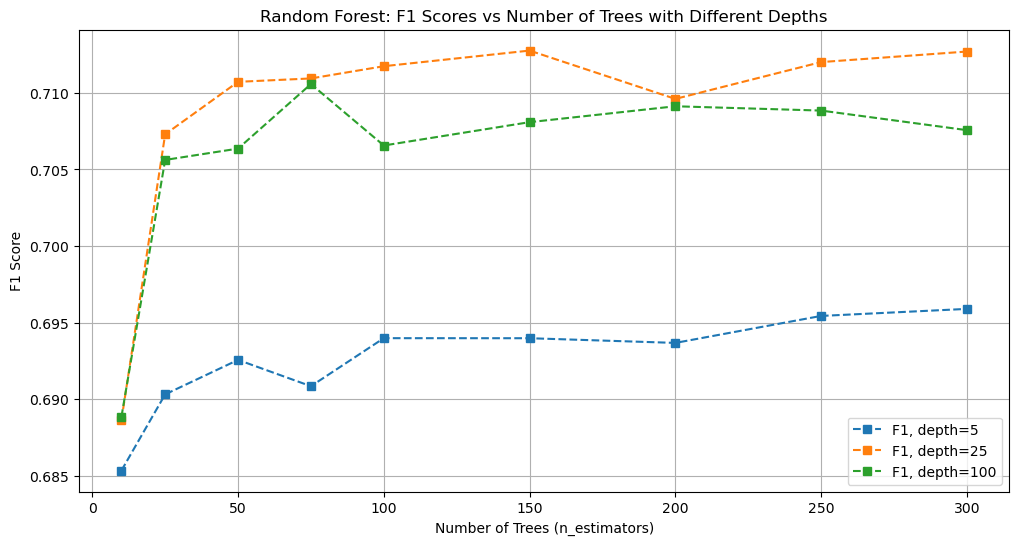

In [77]:
plt.figure(figsize=(12,6))

for depth in [5, 25, 100]:
    subset = scores_df[scores_df['param_max_depth'] == depth]
    plt.plot(subset['param_n_estimators'], subset['mean_test_F1'], marker='s', linestyle='--', label=f'F1, depth={depth}')

plt.title('Random Forest: F1 Scores vs Number of Trees with Different Depths')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('F1 Score')
plt.grid(True)
plt.legend()
# plt.ylim(0.5, 1.0)  # optional zoom
plt.show()

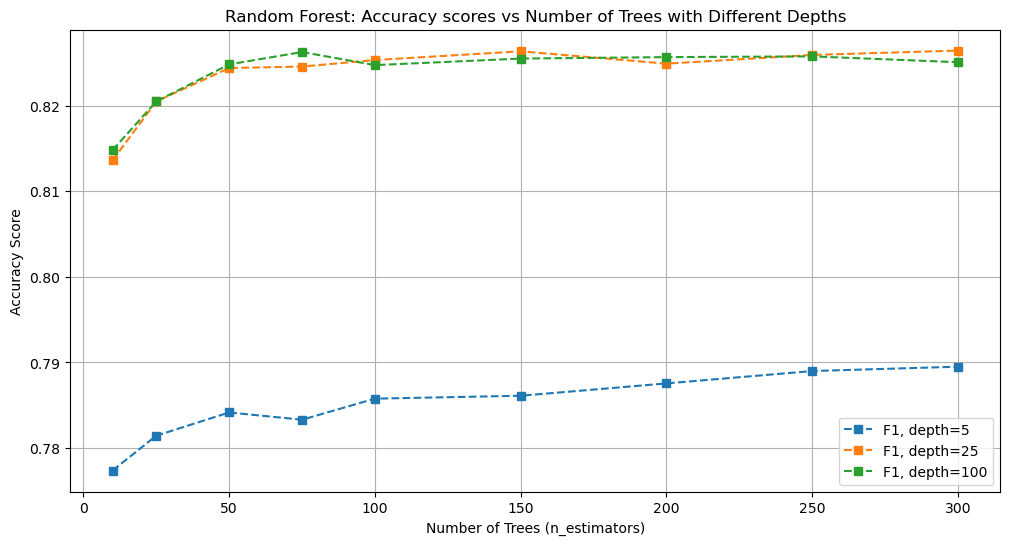

In [78]:
plt.figure(figsize=(12,6))

for depth in [5, 25, 100]:
    subset = scores_df[scores_df['param_max_depth'] == depth]
    plt.plot(subset['param_n_estimators'], subset['mean_test_Accuracy'], marker='s', linestyle='--', label=f'F1, depth={depth}')

plt.title('Random Forest: Accuracy scores vs Number of Trees with Different Depths')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy Score')
plt.grid(True)
plt.legend()
plt.show()


### Discovering Features with most impact.

In [88]:
# y is what we are predicting.
# x are the features.
Y = df['un_profitability']
X = df.drop(columns=['un_profitability'])
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=9)

feature_list = X_train.columns.tolist()
feature_performance = []

# Define and instantiate the Random Forest model with key parameters
num_trees = 150      # Number of trees in the forest
max_depth = 25       # Maximum depth of each tree; adjust as needed
seed = 9             # Seed for reproducibility
weight = 'balanced'  # Handle imbalance by weighting classes
rf_model = RandomForestClassifier(n_estimators=num_trees,
                                  max_depth=max_depth,
                                  random_state=seed,
                                  class_weight=weight)

rf_model.fit(X_train, Y_train)
Y_predictions = rf_model.predict(X_test)

baseline_accuracy = accuracy_score(Y_test, Y_predictions)
baseline_f1 = f1_score(Y_test, Y_predictions)

print("\nBaseline:")
print(classification_report(Y_test, Y_predictions, zero_division=0))


for feature in feature_list:
    reduced_features = [f for f in feature_list if f != feature]
    X_train_reduced = X_train[reduced_features]
    X_test_reduced = X_test[reduced_features]

    rf_model = RandomForestClassifier(n_estimators=num_trees, max_depth=max_depth, random_state=seed, class_weight=weight)
    
    rf_model.fit(X_train_reduced, Y_train)
    Y_predictions_reduced = rf_model.predict(X_test_reduced)

    accuracy = accuracy_score(Y_test, Y_predictions_reduced)
    f1 = f1_score(Y_test, Y_predictions_reduced)
    feature_performance.append((feature, accuracy, f1))

performance_df = pd.DataFrame(feature_performance, columns=['Feature_Removed', 'Accuracy_Score_After_Removal', 'F1_Score_After_Removal'])

# Calculate Accuracy Drop
performance_df['Accuracy_Drop'] = baseline_accuracy - performance_df['Accuracy_Score_After_Removal']
# Calculate F1 Drop
performance_df['F1_Drop'] = baseline_f1 - performance_df['F1_Score_After_Removal']

# Sort by largest Accuracy drop
performance_df = performance_df.sort_values('Accuracy_Drop', ascending=False)
print("\nFeature Importance Based on Accuracy  Drop:")
print(performance_df.head(5))

# Sort by largest F1 drop
performance_df = performance_df.sort_values('F1_Drop', ascending=False)
print("\nFeature Importance Based on F1 Drop:")
print(performance_df.head(5))



Baseline:
              precision    recall  f1-score   support

           0       0.83      0.94      0.89      3267
           1       0.86      0.66      0.75      1783

    accuracy                           0.84      5050
   macro avg       0.85      0.80      0.82      5050
weighted avg       0.84      0.84      0.84      5050


Feature Importance Based on Accuracy  Drop:
   Feature_Removed  Accuracy_Score_After_Removal  F1_Score_After_Removal  \
5        actor_med                      0.817228                0.699837   
8   production_med                      0.823168                0.716057   
9   production_dev                      0.832871                0.728792   
10    release_year                      0.833663                0.731286   
1       vote_count                      0.833861                0.730831   

    Accuracy_Drop   F1_Drop  
5        0.025149  0.046336  
8        0.019208  0.030116  
9        0.009505  0.017382  
10       0.008713  0.014887  
1        0